In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Perceptron
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error, root_mean_squared_error,accuracy_score,classification_report


In [2]:
df=pd.read_csv("mysalary.csv")
df

,Experience,Education_Level,Salary
0,1,1,22000
1,2,1,25000
2,3,1,28000
3,4,1,31000
4,5,1,34000
5,1,2,27000
6,2,2,30000
7,3,2,33000
8,4,2,36000
9,5,2,39000


In [3]:
print(df.shape)
print(df.columns)

(30, 3)
Index(['Experience', 'Education_Level', 'Salary'], dtype='str')


In [4]:
x=df.iloc[:,0:2]
y=df.iloc[:,2]

print("Features :\n",x.head())
print("\nTarget :\n",y.head())

Features :
    Experience  Education_Level
0           1                1
1           2                1
2           3                1
3           4                1
4           5                1

Target :
 0    22000
1    25000
2    28000
3    31000
4    34000
Name: Salary, dtype: int64


In [5]:
y

0     22000
1     25000
2     28000
3     31000
4     34000
5     27000
6     30000
7     33000
8     36000
9     39000
10    42000
11    34000
12    37000
13    40000
14    43000
15    46000
16    49000
17    41000
18    44000
19    47000
20    50000
21    53000
22    56000
23    48000
24    51000
25    54000
26    57000
27    60000
28    63000
29    66000
Name: Salary, dtype: int64

# i) Split the dataset 80%-20% for train and test 

In [6]:
x_train, x_test , y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state= 42
)

print(f"Training data: {x_train.shape}")
print(f"Testing data: {x_test.shape}")

Training data: (24, 2)
Testing data: (6, 2)


# ii) Train the model with linear regression model 

In [7]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[2958.23,4257.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Experience','Education_Level']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.521e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [8]:
y_pred_lr=lr_model.predict(x_test)
print("Linear Regression Predictions:")

print(y_pred_lr)

Linear Regression Predictions:
[60161.57215693 45730.47370563 48328.6497355  41113.10050985
 35556.69387462 38514.92447998]


# Regression metrics

In [9]:
r2_lr=r2_score(y_test,y_pred_lr)
mae_lr=mean_absolute_error(y_test,y_pred_lr)
mse_lr=mean_squared_error(y_test,y_pred_lr)
rmse_lr=root_mean_squared_error(y_test,y_pred_lr)

print("Linear Regression")
print("R2 :", r2_lr)
print("MAE :", mae_lr)
print("MSE :",mse_lr)
print("RMSE :",rmse_lr)

Linear Regression
R2 : 0.9982299702713303
MAE : 300.2050570090384
MSE : 108561.82335840969
RMSE : 329.4872127388401


In [10]:
median_salary=df["Salary"].median()

df["Salary_class"]=(df["Salary"]>=median_salary).astype(int)
print(df.head())

   Experience  Education_Level  Salary  Salary_class
0           1                1   22000             0
1           2                1   25000             0
2           3                1   28000             0
3           4                1   31000             0
4           5                1   34000             0


In [11]:
df

,Experience,Education_Level,Salary,Salary_class
0,1,1,22000,0
1,2,1,25000,0
2,3,1,28000,0
3,4,1,31000,0
4,5,1,34000,0
5,1,2,27000,0
6,2,2,30000,0
7,3,2,33000,0
8,4,2,36000,0
9,5,2,39000,0


# iii) Train the model with a perceptron [Use sklearn library]

In [15]:
x1=df.iloc[:,0:2]
y1=df["Salary_class"]

x1_train_p , x1_test_p, y1_train_p, y1_test_p=train_test_split(
    x1,
    y1,
    test_size=0.2,
    random_state=42
)

print(f"Training Data : {x1_train_p.shape}")
print(f"Testing Data : {x1_test_p.shape}")

Training Data : (24, 2)
Testing Data : (6, 2)


In [18]:
prcpt_model=Perceptron(
    random_state=42
)

prcpt_model.fit(x1_train_p,y1_train_p)

,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [19]:
y1_pred_P=prcpt_model.predict(x1_test_p)

print("Perceptron Prediction")
print(y1_pred_P)

Perceptron Prediction
[1 1 1 1 0 0]


In [ ]:
accuracy_score_p=accuracy_score(y1_test_p,y1_pred_P)

print("Perceptron Accuracy :",accuracy_score_p)
print(classification_report(y1_test_p,y1_pred_P))

Perceptron Accuracy : 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



In [24]:
print("="*45)
print("Model Performance Comparison")
print("="*45)

print("\nLinear Regression:")
print("R^2    :",round(r2_lr,4))
print("MAE    :",round(mae_lr,2))
print("RMSE   :",round(rmse_lr,2))


print("\nPerceptron")
print("accuracy :",round(accuracy_score_p,4))

Model Performance Comparison

Linear Regression:
R^2    : 0.9982
MAE    : 300.21
RMSE   : 329.49

Perceptron
accuracy : 0.8333


# Model Performance Comparison by graph

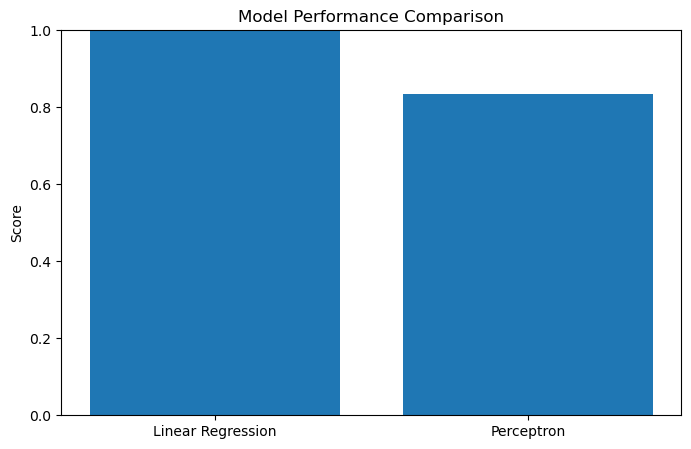

In [27]:
models=["Linear Regression", "Perceptron"]
scores=[r2_lr,accuracy_score_p]

plt.figure(figsize=(8,5))
plt.bar(models,scores)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0,1)

plt.show()

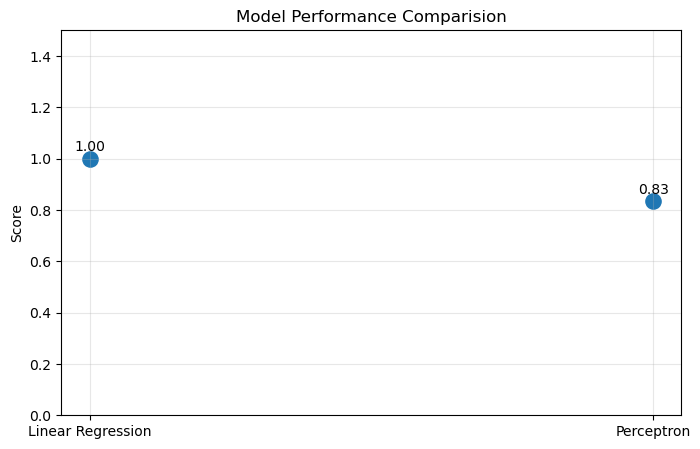

In [29]:
models=["Linear Regression", "Perceptron"]
scores=[r2_lr,accuracy_score_p]

plt.figure(figsize=(8,5))
plt.scatter(models,scores,s=120)

plt.ylabel("Score")
plt.title("Model Performance Comparision")
plt.ylim(0,1.5)
plt.grid(True,alpha=0.3)

for i , score in enumerate(scores):
    plt.text(i,score+0.03, f"{score:.2f}",ha="center")

plt.show()